# Day 2: FedAvg-MeZO — visualization

Pure visualizer for `outputs/day2_fedavg.json`. **No training here** —
heavy runs live in `scripts/run_fedavg.py`. Re-run that script to
regenerate the JSON, then re-run this notebook to refresh the plots.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FED_PATH = ROOT / 'outputs' / 'day2_fedavg.json'
DAY1_PATH = ROOT / 'outputs' / 'day1_baselines_full.json'

fed = json.loads(FED_PATH.read_text())
day1 = json.loads(DAY1_PATH.read_text()) if DAY1_PATH.exists() else None

print('FedAvg configs in JSON:')
print(f"  N sweep: {sorted(fed['n_sweep'].keys(), key=int)}")
print(f"  K sweep: {sorted(fed['k_sweep'].keys(), key=int)}")
if day1:
    print(f"Day-1 baselines: zero-shot={day1['init_val_acc']:.4f}, "
          f"single-MeZO={day1['mezo']['eval_acc'][-1]:.4f}, "
          f"AdamW={day1['adamw']['eval_acc'][-1]:.4f}")

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (9, 5)

FedAvg configs in JSON:
  N sweep: ['1', '2', '4', '8']
  K sweep: ['1', '10', '100', '1000']
Day-1 baselines: zero-shot=0.7775, single-MeZO=0.9094, AdamW=0.8922


## Experiment 1 — N sweep (K fixed)

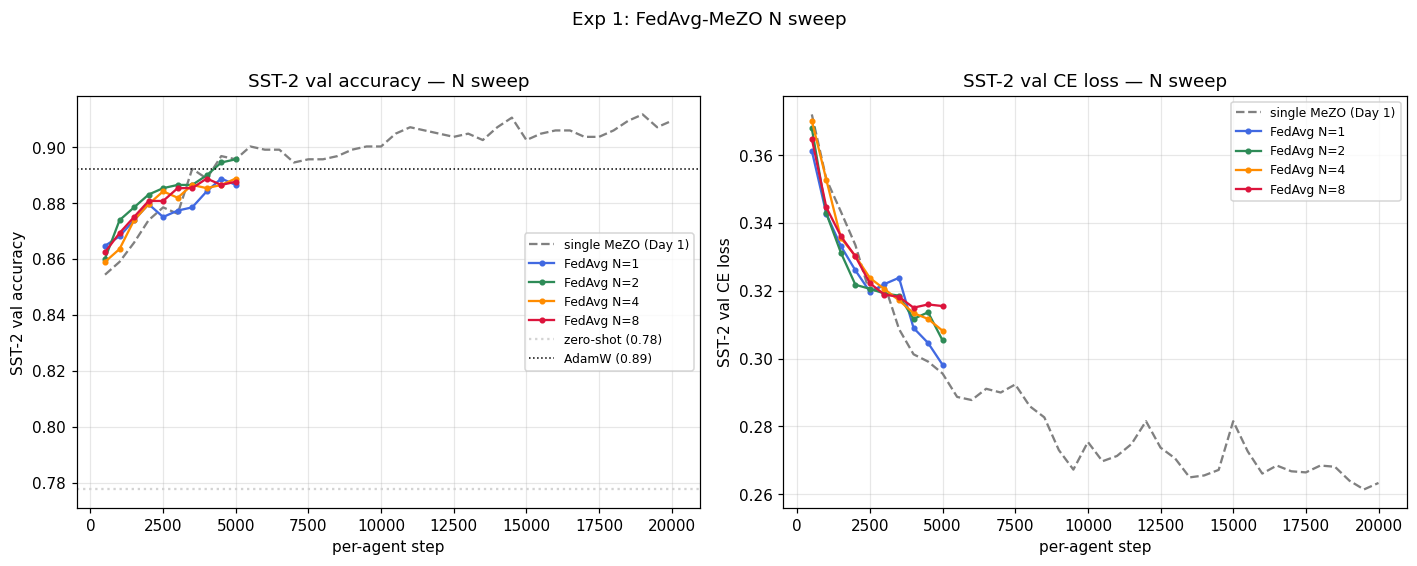

In [2]:
colors = ['royalblue', 'seagreen', 'darkorange', 'crimson']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, key, ylabel in [
    (axes[0], 'eval_acc', 'SST-2 val accuracy'),
    (axes[1], 'eval_loss', 'SST-2 val CE loss'),
]:
    if day1:
        sm = day1['mezo']
        ax.plot(sm['eval_step'], sm[key], '--', color='gray',
                label='single MeZO (Day 1)', linewidth=1.5)
    for n_str, c in zip(sorted(fed['n_sweep'].keys(), key=int), colors):
        h = fed['n_sweep'][n_str]
        ax.plot(h['eval_step'], h[key], marker='o', markersize=3, color=c,
                label=f"FedAvg N={n_str}")
    if day1 and key == 'eval_acc':
        ax.axhline(day1['init_val_acc'], color='lightgray', linestyle=':',
                   label=f"zero-shot ({day1['init_val_acc']:.2f})")
        ax.axhline(day1['adamw']['eval_acc'][-1], color='black',
                   linestyle=':', linewidth=1,
                   label=f"AdamW ({day1['adamw']['eval_acc'][-1]:.2f})")
    ax.set_xlabel('per-agent step'); ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} — N sweep")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Exp 1: FedAvg-MeZO N sweep', y=1.02)
plt.tight_layout()

## Experiment 2 — K sweep (N fixed)

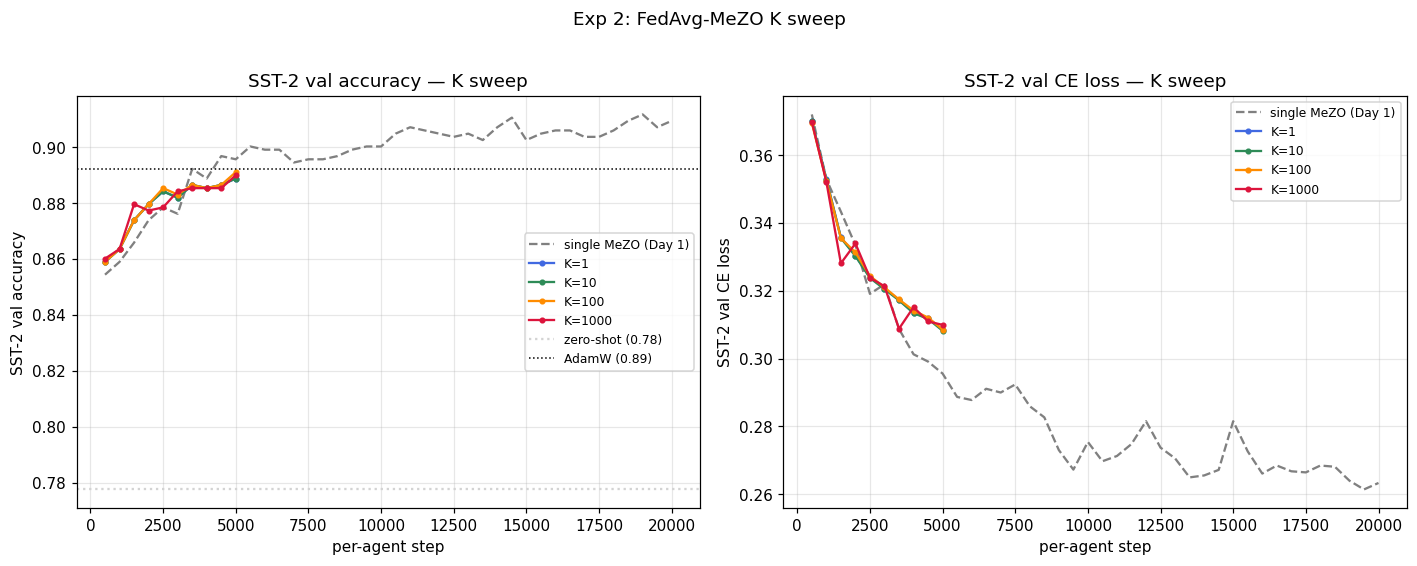

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, key, ylabel in [
    (axes[0], 'eval_acc', 'SST-2 val accuracy'),
    (axes[1], 'eval_loss', 'SST-2 val CE loss'),
]:
    if day1:
        sm = day1['mezo']
        ax.plot(sm['eval_step'], sm[key], '--', color='gray',
                label='single MeZO (Day 1)', linewidth=1.5)
    for k_str, c in zip(sorted(fed['k_sweep'].keys(), key=int), colors):
        h = fed['k_sweep'][k_str]
        ax.plot(h['eval_step'], h[key], marker='o', markersize=3, color=c,
                label=f"K={k_str}")
    if day1 and key == 'eval_acc':
        ax.axhline(day1['init_val_acc'], color='lightgray', linestyle=':',
                   label=f"zero-shot ({day1['init_val_acc']:.2f})")
        ax.axhline(day1['adamw']['eval_acc'][-1], color='black',
                   linestyle=':', linewidth=1,
                   label=f"AdamW ({day1['adamw']['eval_acc'][-1]:.2f})")
    ax.set_xlabel('per-agent step'); ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} — K sweep")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Exp 2: FedAvg-MeZO K sweep', y=1.02)
plt.tight_layout()

## Summary table

In [4]:
rows = []
if day1:
    rows += [
        {'method': 'zero-shot',   'N': '-', 'K': '-',
         'val_acc': f"{day1['init_val_acc']:.4f}"},
        {'method': 'single MeZO', 'N': 1,   'K': '-',
         'val_acc': f"{day1['mezo']['eval_acc'][-1]:.4f}"},
        {'method': 'AdamW',       'N': '-', 'K': '-',
         'val_acc': f"{day1['adamw']['eval_acc'][-1]:.4f}"},
    ]
K_FIXED = 10   # local_steps used in the N-sweep (see scripts/run_fedavg.py)
N_FIXED = 4    # n_agents used in the K-sweep
for n_str in sorted(fed['n_sweep'].keys(), key=int):
    rows.append({'method': 'FedAvg', 'N': int(n_str), 'K': K_FIXED,
                 'val_acc': f"{fed['n_sweep'][n_str]['eval_acc'][-1]:.4f}"})
for k_str in sorted(fed['k_sweep'].keys(), key=int):
    rows.append({'method': 'FedAvg', 'N': N_FIXED, 'K': int(k_str),
                 'val_acc': f"{fed['k_sweep'][k_str]['eval_acc'][-1]:.4f}"})
pd.DataFrame(rows)

,method,N,K,val_acc
0,zero-shot,-,-,0.7775
1,single MeZO,1,-,0.9094
2,AdamW,-,-,0.8922
3,FedAvg,1,10,0.8865
4,FedAvg,2,10,0.8956
5,FedAvg,4,10,0.8888
6,FedAvg,8,10,0.8876
7,FedAvg,4,1,0.8888
8,FedAvg,4,10,0.8888
9,FedAvg,4,100,0.8911


## Summary table — val loss

In [5]:
rows = []
if day1:
    rows += [
        {'method': 'single MeZO', 'N': 1,   'K': '-',
         'val_loss': f"{day1['mezo']['eval_loss'][-1]:.4f}"},
        {'method': 'AdamW',       'N': '-', 'K': '-',
         'val_loss': f"{day1['adamw']['eval_loss'][-1]:.4f}"},
    ]
for n_str in sorted(fed['n_sweep'].keys(), key=int):
    rows.append({'method': 'FedAvg', 'N': int(n_str), 'K': K_FIXED,
                 'val_loss': f"{fed['n_sweep'][n_str]['eval_loss'][-1]:.4f}"})
for k_str in sorted(fed['k_sweep'].keys(), key=int):
    rows.append({'method': 'FedAvg', 'N': N_FIXED, 'K': int(k_str),
                 'val_loss': f"{fed['k_sweep'][k_str]['eval_loss'][-1]:.4f}"})
pd.DataFrame(rows)

,method,N,K,val_loss
0,single MeZO,1,-,0.2633
1,AdamW,-,-,0.3390
2,FedAvg,1,10,0.2981
3,FedAvg,2,10,0.3053
4,FedAvg,4,10,0.3082
5,FedAvg,8,10,0.3155
6,FedAvg,4,1,0.3085
7,FedAvg,4,10,0.3082
8,FedAvg,4,100,0.3086
9,FedAvg,4,1000,0.3099
